<a href="https://colab.research.google.com/github/shoh0806/Capstone_Design/blob/main/SASRec_Analysis_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ===== 0. 드라이브 마운트 =====

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ===== 1. import =====

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch import optim
from typing import Optional, Tuple
import math
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
import matplotlib.font_manager as fm
fm.fontManager.__init__()
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ===== 2. SEED 고정 =====

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"Device: {device}")

Device: cuda


# ===== 3. 하이퍼파라미터 =====

In [ ]:
DATA_DIR   = "/content/drive/MyDrive"
max_len    = 100
hidden_dim = 100
num_heads  = 4
num_layers = 4

# ===== 4. 데이터 로드 =====

In [ ]:
ratings = pd.read_csv(os.path.join(DATA_DIR, "ratings.csv"))
ratings = ratings.sort_values(by=["userId", "timestamp"])
user_seq = ratings.groupby("userId")["movieId"].apply(list)

item_set = sorted(ratings["movieId"].unique())
item2idx = {item: i+1 for i, item in enumerate(item_set)}
idx2item = {i: item for item, i in item2idx.items()}

user_sequences = [[item2idx[i] for i in seq] for seq in user_seq]
user_ids = list(user_seq.index)

# Train / Val / Test 분리
test_data    = []
test_user_ids = []

for uid, seq in zip(user_ids, user_sequences):
    if len(seq) < 20:
        continue
    train = seq[:-2]
    val   = seq[-2]
    test  = seq[-1]
    test_data.append((train + [val], [test]))
    test_user_ids.append(uid)

print(f"테스트 유저 수: {len(test_data)}")

테스트 유저 수: 6040


# ===== 5. SASRec 클래스 정의 =====

In [ ]:
class SASRecBlock(nn.Module):
    def __init__(self, hidden_dim, num_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads,
            dropout=0.2, batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Linear(hidden_dim * 4, hidden_dim)
        )
        self.norm1   = nn.LayerNorm(hidden_dim)
        self.norm2   = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x, attn_mask, padding_mask):
        attn_output, attn_weights = self.attn(
            x, x, x,
            attn_mask=attn_mask,
            key_padding_mask=padding_mask,
            need_weights=True,
            average_attn_weights=False
        )
        attn_output = self.dropout(attn_output)
        x = self.norm1(x + attn_output)
        ffn_output = self.ffn(x)
        ffn_output = self.dropout(ffn_output)
        x = self.norm2(x + ffn_output)
        return x, attn_weights

class SASRec(nn.Module):
    def __init__(self, num_items, hidden_dim, max_len, num_heads, num_layers):
        super().__init__()
        self.item_emb = nn.Embedding(num_items + 1, hidden_dim, padding_idx=0)
        self.pos_emb  = nn.Embedding(max_len, hidden_dim)
        self.layers   = nn.ModuleList([
            SASRecBlock(hidden_dim, num_heads) for _ in range(num_layers)
        ])
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout    = nn.Dropout(0.2)

    def forward(self, batch_input):
        batch_size, seq_len = batch_input.size()
        pos = torch.arange(seq_len, device=batch_input.device).unsqueeze(0).repeat(batch_size, 1)
        x = self.item_emb(batch_input) * math.sqrt(self.item_emb.embedding_dim)
        x = x + self.pos_emb(pos)
        x = self.dropout(x)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1)
        mask = mask.masked_fill(mask == 1, -1e9).float()
        padding_mask = (batch_input == 0)
        x = x.masked_fill(padding_mask.unsqueeze(-1), 0)
        attn_weights_all = []
        for layer in self.layers:
            x, attn_weights = layer(x, mask, padding_mask)
            attn_weights_all.append(attn_weights)
        x = self.layer_norm(x)
        return x, attn_weights_all

# ===== 6. BERT4Rec 클래스 정의 =====

In [ ]:
class CustomTransformerEncoderLayer(nn.TransformerEncoderLayer):
    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        x = src
        attn_output, attn_weights = self.self_attn(
            x, x, x,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True
        )
        x = x + self.dropout1(attn_output)
        x = self.norm1(x)
        x = x + self.dropout2(self.linear2(self.dropout(self.activation(self.linear1(x)))))
        x = self.norm2(x)
        return x, attn_weights

class BERT4RecWithAttn(nn.Module):
    def __init__(self, num_items, embed_dim=128, nhead=4, num_layers=4, maxlen=100, dropout=0.1):
        super().__init__()
        self.item_emb = nn.Embedding(num_items + 2, embed_dim, padding_idx=0)
        self.pos_emb  = nn.Embedding(maxlen, embed_dim)
        self.emb_layernorm = nn.LayerNorm(embed_dim)
        self.dropout  = nn.Dropout(dropout)
        self.layers   = nn.ModuleList([
            CustomTransformerEncoderLayer(
                d_model=embed_dim, nhead=nhead,
                dim_feedforward=embed_dim*4,
                dropout=dropout, batch_first=True,
                activation='gelu'
            ) for _ in range(num_layers)
        ])
        self.out_layer = nn.Linear(embed_dim, num_items + 2)

    def forward(self, x, return_attn=False):
        batch_size, seq_len = x.size()
        pos = torch.arange(seq_len, device=x.device).unsqueeze(0).repeat(batch_size, 1)
        e = self.dropout(self.emb_layernorm(self.item_emb(x) + self.pos_emb(pos)))
        output = e
        all_attentions = []
        for layer in self.layers:
            output, attn_w = layer(output)
            all_attentions.append(attn_w)
        logits = self.out_layer(output)
        if return_attn:
            return logits, all_attentions
        return logits

# ===== 7. SASRec 모델 불러오기 =====

In [ ]:
sas_model = SASRec(len(item2idx), hidden_dim, max_len, num_heads, num_layers).to(device)
sas_model.load_state_dict(torch.load(os.path.join(DATA_DIR, "sasrec_best.pt")))
sas_model.eval()
print("SASRec 로드 완료!")




SASRec 로드 완료!


# ===== 8. BERT4Rec 모델 불러오기 =====

In [ ]:
bert_model = BERT4RecWithAttn(len(item2idx), embed_dim=128, nhead=4, num_layers=4, maxlen=100).to(device)

# 키 이름 변환해서 불러오기
state_dict = torch.load(os.path.join(DATA_DIR, "model_L4.pth"))
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('transformer_blocks.layers.'):
        new_k = k.replace('transformer_blocks.layers.', 'layers.')
        new_state_dict[new_k] = v
    else:
        new_state_dict[k] = v

bert_model.load_state_dict(new_state_dict)
bert_model.eval()
print("BERT4Rec 로드 완료!")

BERT4Rec 로드 완료!


# ===== 9. 실험 06 - SASRec vs BERT4Rec Attention 비교 =====

둘 다 맞춘 유저 찾는 중...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


둘 다 맞춘 유저 5명 발견!


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


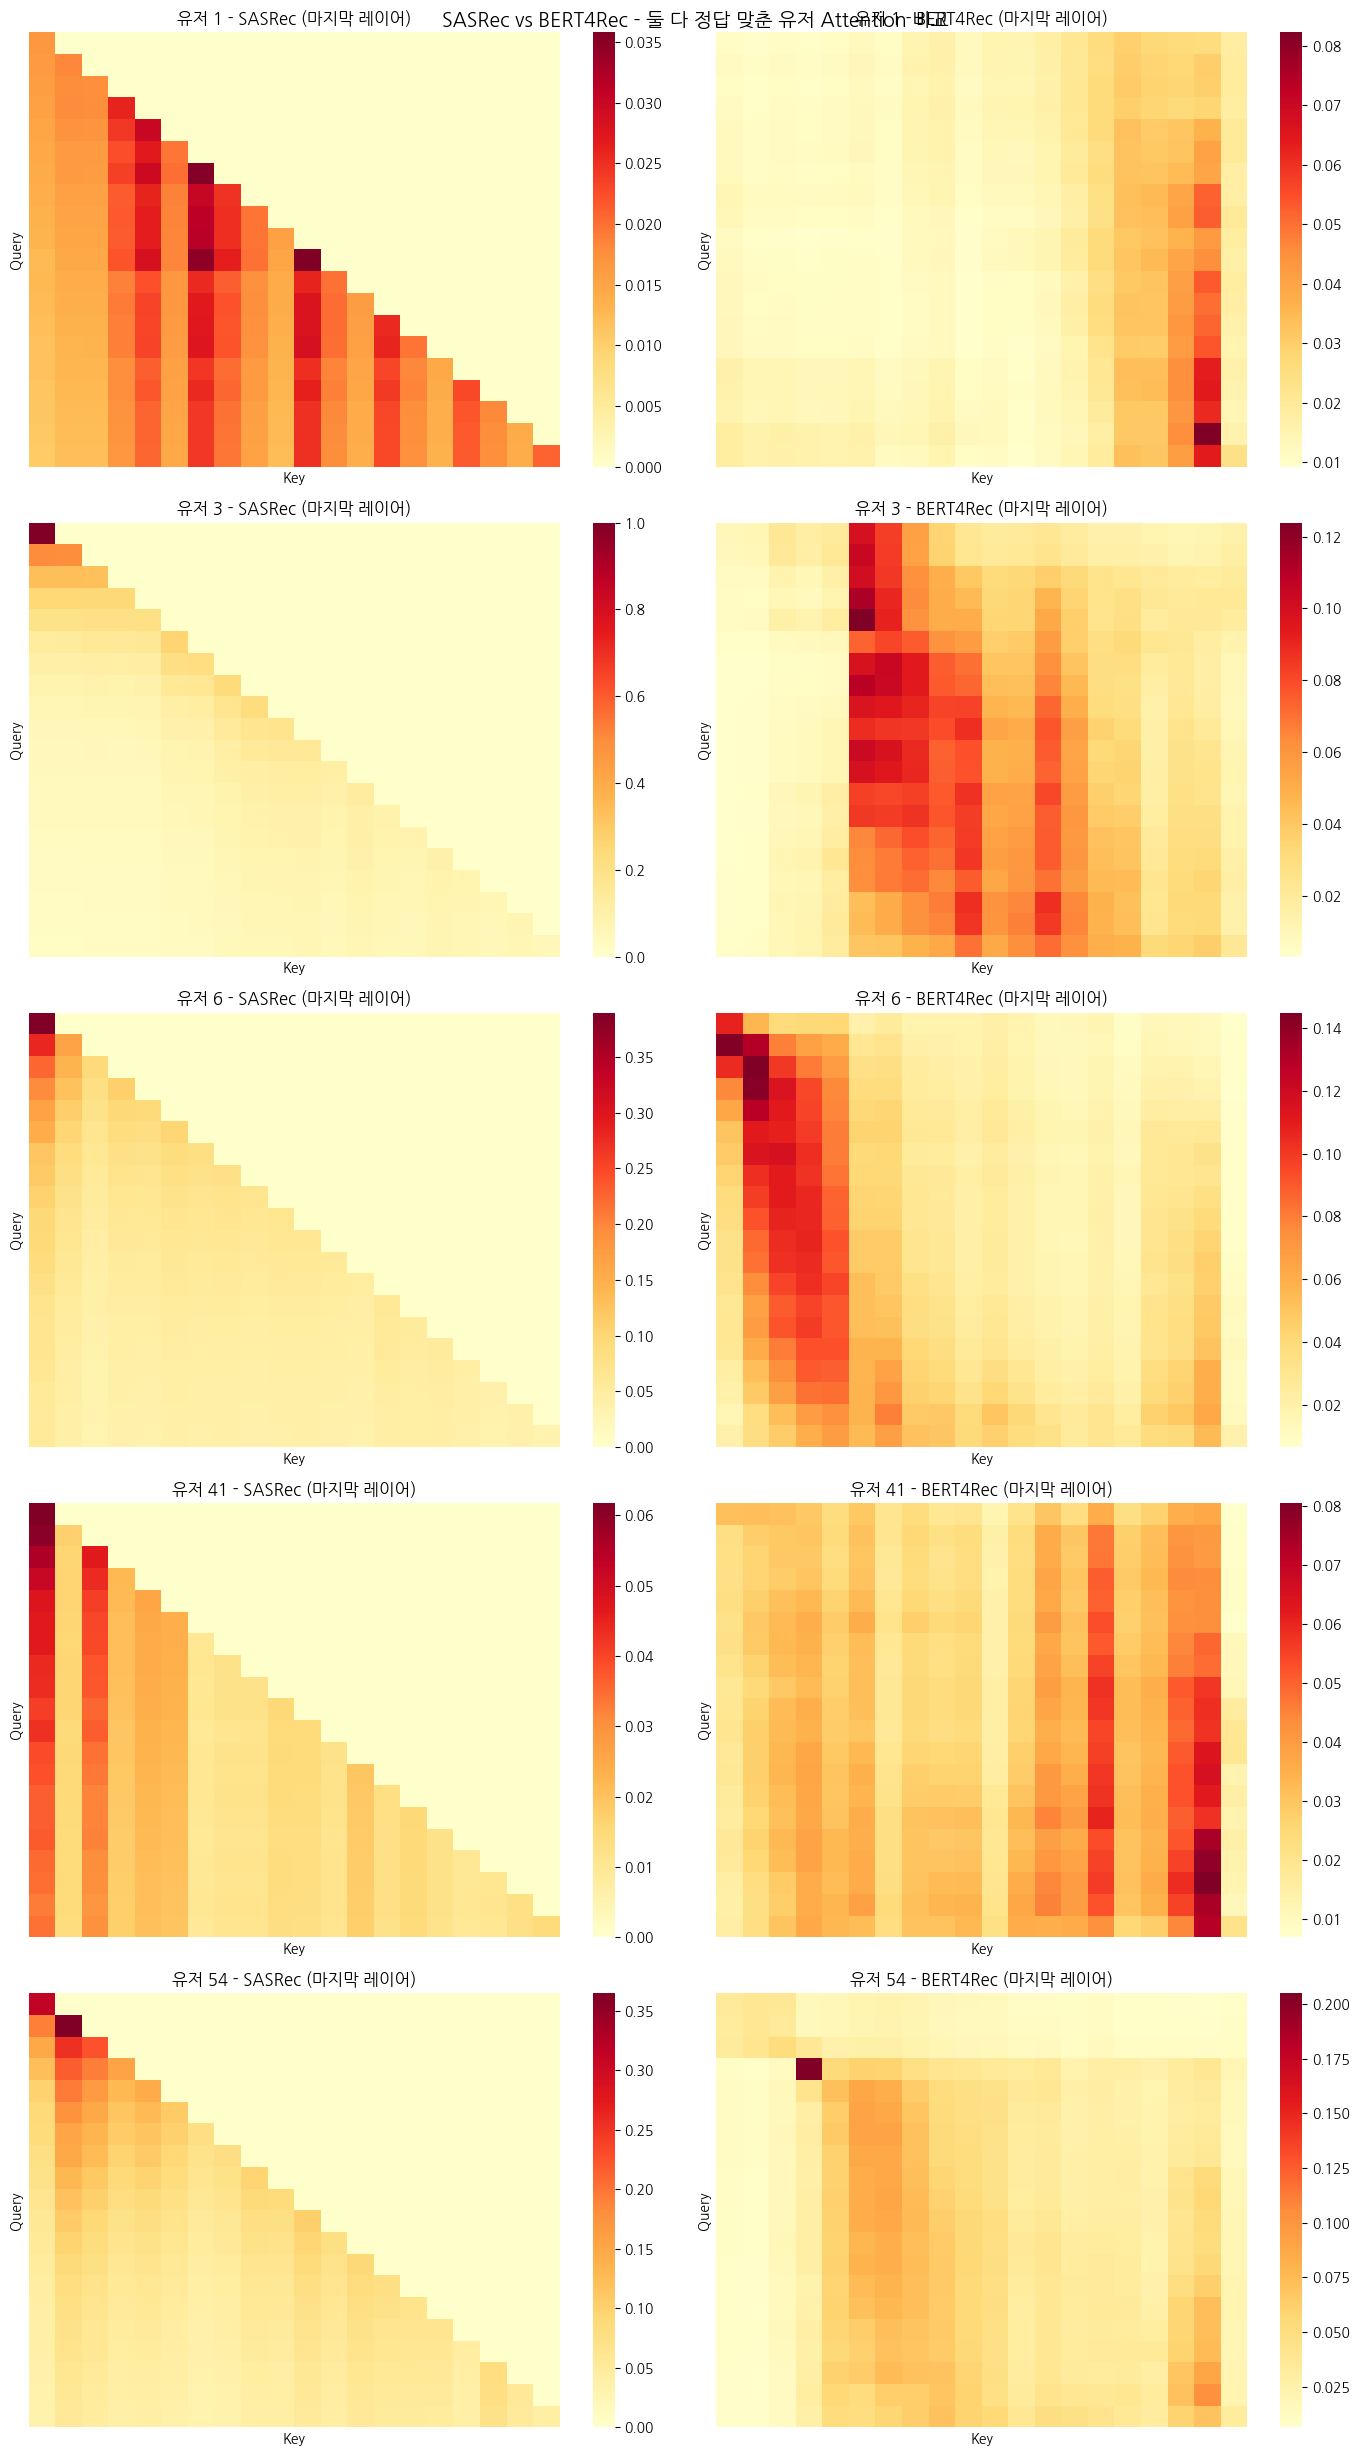

In [ ]:
mask_token = len(item2idx) + 1  # BERT4Rec 마스크 토큰

def get_sas_attention(model, seq, n_tokens=20):
    model.eval()
    with torch.no_grad():
        s = seq[-max_len:]
        s = [0] * (max_len - len(s)) + s
        inp = torch.LongTensor([s]).to(device)
        _, attn_all = model(inp)
    # 마지막 레이어 attention, 헤드 평균
    avg = attn_all[-1][0].mean(dim=0).cpu().numpy()
    return avg[-n_tokens:, -n_tokens:]

def get_bert_attention(model, seq, n_tokens=20):
    model.eval()
    with torch.no_grad():
        s = seq[-max_len:]
        s = [0] * (max_len - len(s)) + s
        s[-1] = mask_token
        inp = torch.LongTensor([s]).to(device)
        _, attn_all = model(inp, return_attn=True)
    # BERT4Rec은 이미 헤드 평균됨 → .mean() 안 해도 됨
    avg = attn_all[-1][0].cpu().numpy()  # (seq_len, seq_len)
    return avg[-n_tokens:, -n_tokens:]

def check_correct(model_type, seq, gt_idx):
    """모델이 정답을 Top10 안에 맞췄는지 확인"""
    with torch.no_grad():
        s = seq[-max_len:]
        s_pad = [0] * (max_len - len(s)) + s
        inp = torch.LongTensor([s_pad]).to(device)

        if model_type == 'sas':
            output, _ = sas_model(inp)
            h = output[:, -1, :]
            scores = torch.matmul(h, sas_model.item_emb.weight.T).squeeze()
            scores[0] = -1e9
            for seen in seq:
                scores[seen] = -1e9
        else:
            s_bert = s_pad.copy()
            s_bert[-1] = mask_token
            inp_bert = torch.LongTensor([s_bert]).to(device)
            logits = bert_model(inp_bert)
            scores = logits[0, -1, :]
            scores[0] = -1e9
            scores[mask_token] = -1e9

        rank = (scores > scores[gt_idx]).sum().item()
        return rank < 10

# 둘 다 맞춘 유저 찾기
print("둘 다 맞춘 유저 찾는 중...")
both_correct = []
for i, (seq, gt) in enumerate(test_data):
    gt_idx = gt[0]
    sas_ok  = check_correct('sas', seq, gt_idx)
    bert_ok = check_correct('bert', seq, gt_idx)
    if sas_ok and bert_ok:
        both_correct.append(i)
    if len(both_correct) >= 5:  # 5명만 찾으면 충분
        break

print(f"둘 다 맞춘 유저 {len(both_correct)}명 발견!")

# Attention 히트맵 비교 시각화
fig, axes = plt.subplots(len(both_correct), 2, figsize=(14, 5 * len(both_correct)))

for row, idx in enumerate(both_correct):
    seq, gt = test_data[idx]

    sas_attn  = get_sas_attention(sas_model, seq)
    bert_attn = get_bert_attention(bert_model, seq)

    sns.heatmap(sas_attn, ax=axes[row, 0], cmap="YlOrRd",
                xticklabels=False, yticklabels=False)
    axes[row, 0].set_title(f"유저 {idx} - SASRec (마지막 레이어)")
    axes[row, 0].set_xlabel("Key")
    axes[row, 0].set_ylabel("Query")

    sns.heatmap(bert_attn, ax=axes[row, 1], cmap="YlOrRd",
                xticklabels=False, yticklabels=False)
    axes[row, 1].set_title(f"유저 {idx} - BERT4Rec (마지막 레이어)")
    axes[row, 1].set_xlabel("Key")
    axes[row, 1].set_ylabel("Query")

plt.suptitle("SASRec vs BERT4Rec - 둘 다 정답 맞춘 유저 Attention 비교", fontsize=14)
plt.tight_layout()
plt.show()